# Exploración de `movies`

## Importación de librerías y datos

In [1]:
import os
import sys

project_root = os.path.abspath('../../..')
sys.path.insert(0, os.path.join(project_root, 'src'))

from parcial_digd import utils_

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
movies = pd.read_csv('../../../data/processed/movies.csv')
movies = utils_.get_genre_columns(movies)

## Descripción del conjunto de datos

`movies.csv` contiene el catálogo de películas del dataset MovieLens ya procesado. Cada fila representa **una película única**, identificada por `movieId`.

Al cargar los datos se aplica `utils_.get_genre_columns`, que transforma la columna original `genres` (géneros separados por `|`) en un conjunto de columnas binarias, una por cada género válido según la documentación de MovieLens, más una columna `None` que indica que la película no pertenece a ninguno de esos géneros. Esta función no considera `IMAX` como género (se trata como formato, no género), por lo que la única película cuyo único valor en `genres` era `IMAX` queda marcada con `None = 1`.

In [6]:
print(f"Dimensiones: {movies.shape[0]} filas x {movies.shape[1]} columnas")
movies.info()

Dimensiones: 86967 filas x 22 columnas
<class 'pandas.DataFrame'>
RangeIndex: 86967 entries, 0 to 86966
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movieId       86967 non-null  int64
 1   title         86967 non-null  str  
 2   release_year  86967 non-null  str  
 3   Action        86967 non-null  int64
 4   Adventure     86967 non-null  int64
 5   Animation     86967 non-null  int64
 6   Children      86967 non-null  int64
 7   Comedy        86967 non-null  int64
 8   Crime         86967 non-null  int64
 9   Documentary   86967 non-null  int64
 10  Drama         86967 non-null  int64
 11  Fantasy       86967 non-null  int64
 12  Film-Noir     86967 non-null  int64
 13  Horror        86967 non-null  int64
 14  Musical       86967 non-null  int64
 15  Mystery       86967 non-null  int64
 16  Romance       86967 non-null  int64
 17  Sci-Fi        86967 non-null  int64
 18  Thriller      86967 non-null  int64
 1

**Resultados:** 86,967 filas y 22 columnas (`movieId`, `title`, `release_year`, 18 géneros binarios y `None`), sin valores nulos aparentes en el resumen de `info()`. 


**Significado de las columnas:**

- `movieId`: identificador numérico único de la película.
- `title`: título de la película (ya sin el año, que fue extraído a `release_year` durante la limpieza).
- `release_year`: año de lanzamiento, almacenado como fecha (`YYYY-01-01`); solo el año es información real, mes y día son un valor fijo de relleno.
- `Action` ... `Western` (18 columnas): indicador binario (1/0) de si la película pertenece a ese género. Una película puede pertenecer a varios géneros simultáneamente.
- `None`: indicador binario de que la película no pertenece a ninguno de los 18 géneros válidos (incluye las películas originalmente marcadas como `(no genres listed)` y el caso especial de `IMAX` mencionado arriba).

**¿Qué se está calculando?** Conteo de valores nulos por columna, de `movieId` duplicados y de filas totalmente duplicadas.

In [7]:
print("Valores nulos por columna:")
print(movies.isnull().sum())
print()
print(f"movieId duplicados: {movies['movieId'].duplicated().sum()}")
print(f"Filas totalmente duplicadas: {movies.duplicated().sum()}")
print(f"Rango de movieId: {movies['movieId'].min()} - {movies['movieId'].max()}")

Valores nulos por columna:
movieId         0
title           0
release_year    0
Action          0
Adventure       0
Animation       0
Children        0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
None            0
dtype: int64

movieId duplicados: 0
Filas totalmente duplicadas: 0
Rango de movieId: 1 - 292757


**Resultados:** no hay valores nulos ni `movieId` duplicados. El rango de `movieId` (hasta 292,757) es mucho mayor que el número de filas (86,967). 


### Transformaciones para la exploración

Se realizan dos transformaciones necesarias para poder analizar el catálogo:

1. Extraer el **año** (`anio`) como entero desde `release_year`, y derivar la **década** (`decada`), para agrupar y graficar por periodo.
2. Calcular `num_generos`: el número de géneros válidos asignados a cada película.

Se estan viendo la cantidad de 20 peliculas

In [11]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
              'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies['release_year'] = pd.to_datetime(movies['release_year'])
movies['anio'] = movies['release_year'].dt.year
movies['decada'] = (movies['anio'] // 10) * 10
movies['num_generos'] = movies[genre_cols].sum(axis=1)

#Se cambia el numero dentro de head para ver la cantidad de peliculas que se quiera.
movies[['title', 'anio', 'decada', 'num_generos']].head(20)

,title,anio,decada,num_generos
0,Toy Story,1995,1990,5
1,Jumanji,1995,1990,3
2,Grumpier Old Men,1995,1990,2
3,Waiting to Exhale,1995,1990,3
4,Father of the Bride Part II,1995,1990,1
5,Heat,1995,1990,3
6,Sabrina,1995,1990,2
7,Tom and Huck,1995,1990,2
8,Sudden Death,1995,1990,1
9,GoldenEye,1995,1990,3


## Exploración univariada

**¿Qué se está calculando?** Número total de películas, periodo cubierto y proporción sin género válido.

In [12]:
n_generos_validos = len(genre_cols)
print(f"Total de películas: {movies.shape[0]:,}")
print(f"Periodo cubierto: {movies['anio'].min()} - {movies['anio'].max()}")
print(f"Número de categorías de género analizadas: {n_generos_validos} (+ categoría 'None')")
print(f"Proporción de películas sin género válido: {movies['None'].mean() * 100:.2f}%")

Total de películas: 86,967
Periodo cubierto: 1874 - 2023
Número de categorías de género analizadas: 18 (+ categoría 'None')
Proporción de películas sin género válido: 7.71%


**Resultados:** el catálogo cubre desde 1874 hasta 2023, con 18 géneros válidos analizados, y un 7.71% de películas sin género válido asignado. 


## Análisis de `movies`

### Estadísticas descriptivas y distribución de la variable temporal

**¿Qué se está calculando?** Estadísticas descriptivas de `anio` (mínimo, máximo, mediana, cuartiles) y cantidad de películas por década.

In [13]:
movies['anio'].describe()

count    86967.000000
mean      1995.354537
std         26.011055
min       1874.000000
25%       1981.000000
50%       2006.000000
75%       2015.000000
max       2023.000000
Name: anio, dtype: float64

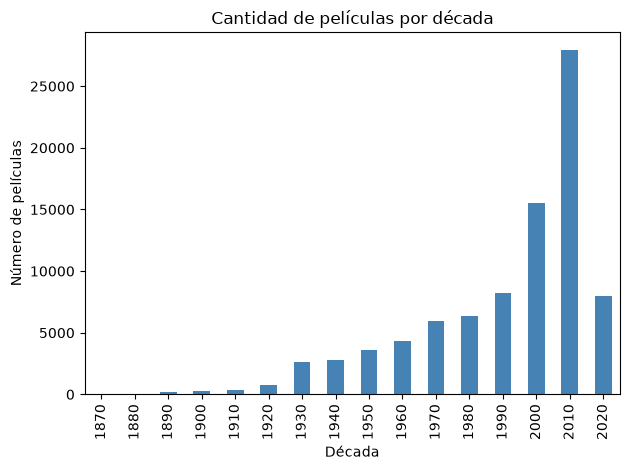

In [14]:
por_decada = movies['decada'].value_counts().sort_index()

plt.figure()
por_decada.plot(kind='bar', color='steelblue')
plt.xlabel('Década')
plt.ylabel('Número de películas')
plt.title('Cantidad de películas por década')
plt.tight_layout()
plt.show()

**Resultados:** la mediana de `anio` es 2005, y la cantidad de películas por década crece de forma sostenida hasta explotar en 2000 y 2010, más de 40,000 películas entre esas dos décadas, casi la mitad del catálogo. Las décadas anteriores a 1900 tienen apenas un puñado de películas. 


### Distribución de la variable categórica: géneros

**¿Qué se está calculando?** Frecuencia absoluta y proporción de películas por cada uno de los 18 géneros válidos (más la categoría `None`).

In [15]:
frecuencias_genero = movies[genre_cols + ['None']].sum().sort_values(ascending=False)
proporciones_genero = (frecuencias_genero / len(movies) * 100).round(2)

pd.DataFrame({'frecuencia': frecuencias_genero, 'porcentaje (%)': proporciones_genero})

,frecuencia,porcentaje (%)
Drama,34095,39.20
Comedy,23077,26.54
Thriller,11784,13.55
Romance,10344,11.89
Action,9651,11.10
Documentary,9296,10.69
Horror,8624,9.92
Crime,6960,8.00
None,6708,7.71
Adventure,5391,6.20


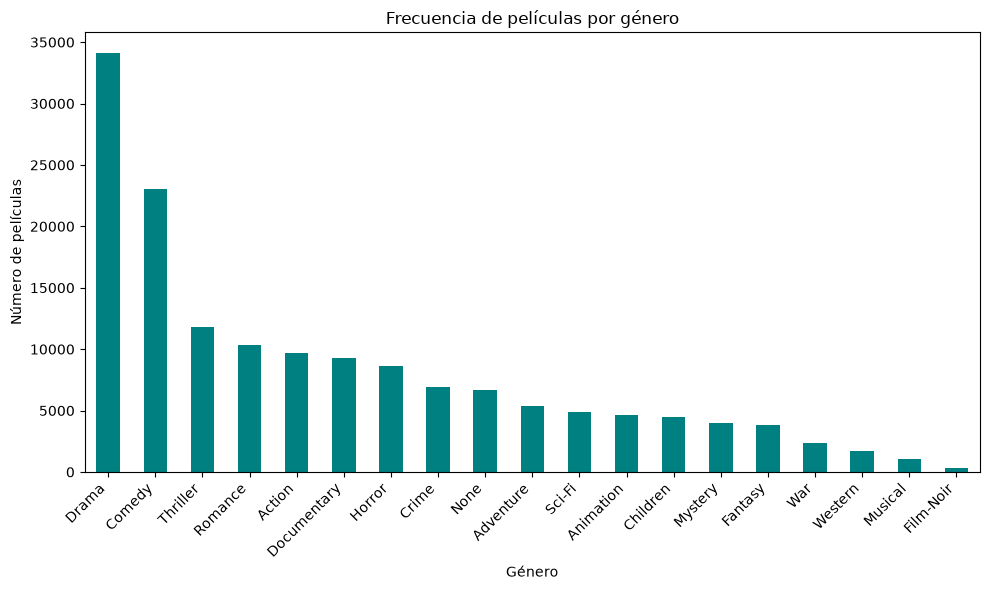

In [16]:
plt.figure(figsize=(10, 6))
frecuencias_genero.plot(kind='bar', color='teal')
plt.xlabel('Género')
plt.ylabel('Número de películas')
plt.title('Frecuencia de películas por género')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Resultados:** `Drama` (34,095 películas, 39.2%) y `Comedy` (23,077, 26.5%) dominan claramente el catálogo. En el otro extremo, `Film-Noir` es el género válido más raro (353 películas, 0.4%). Como cada película puede tener varios géneros, estos porcentajes no suman 100%.

### Estadísticas descriptivas de la variable numérica: número de géneros por película

**¿Qué se está calculando?** Media, mediana, desviación estándar, cuartiles, rango intercuartílico y detección de valores atípicos (regla 1.5×IQR) de `num_generos`.

In [17]:
movies['num_generos'].describe()

count    86967.000000
mean         1.684628
std          1.036006
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: num_generos, dtype: float64

In [18]:
q1, q3 = movies['num_generos'].quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
outliers = movies[movies['num_generos'] > limite_superior]

print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior}")
print(f"Películas con más géneros de lo 'esperado' según la regla IQR: {len(outliers)} ({len(outliers)/len(movies)*100:.1f}%)")

Q1=1.0, Q3=2.0, IQR=1.0
Límite superior (Q3 + 1.5*IQR): 3.5
Películas con más géneros de lo 'esperado' según la regla IQR: 4478 (5.1%)


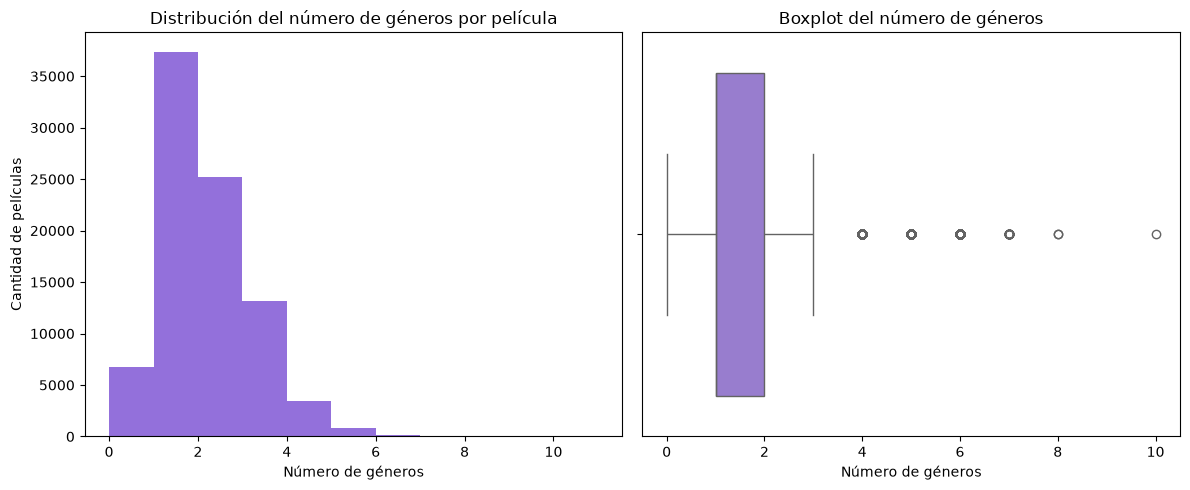

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

movies['num_generos'].plot(kind='hist', bins=range(0, 12), color='mediumpurple', ax=axes[0])
axes[0].set_xlabel('Número de géneros')
axes[0].set_ylabel('Cantidad de películas')
axes[0].set_title('Distribución del número de géneros por película')

sns.boxplot(x=movies['num_generos'], color='mediumpurple', ax=axes[1])
axes[1].set_xlabel('Número de géneros')
axes[1].set_title('Boxplot del número de géneros')

plt.tight_layout()
plt.show()

**Resultados:** media = 1.68, mediana = 1, desviación estándar ≈ 1.04, Q1 = 1 y Q3 = 2 (IQR = 1). Con la regla de 1.5×IQR, el límite superior es 3.5 géneros: 4,478 películas (5.1%) quedan por encima, es decir, tienen 4 o más géneros asignados, la mayoría de las películas tiene 1 o 2 géneros.

### Relaciones entre variables

**¿Qué se está calculando?** Promedio de `num_generos` por década, y evolución de la proporción de los 6 géneros más frecuentes a lo largo de las décadas.

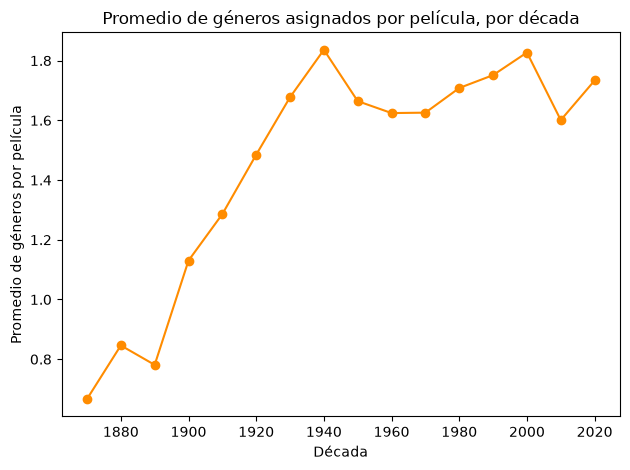

In [20]:
num_generos_por_decada = movies.groupby('decada')['num_generos'].mean()

plt.figure()
num_generos_por_decada.plot(kind='line', marker='o', color='darkorange')
plt.xlabel('Década')
plt.ylabel('Promedio de géneros por película')
plt.title('Promedio de géneros asignados por película, por década')
plt.tight_layout()
plt.show()

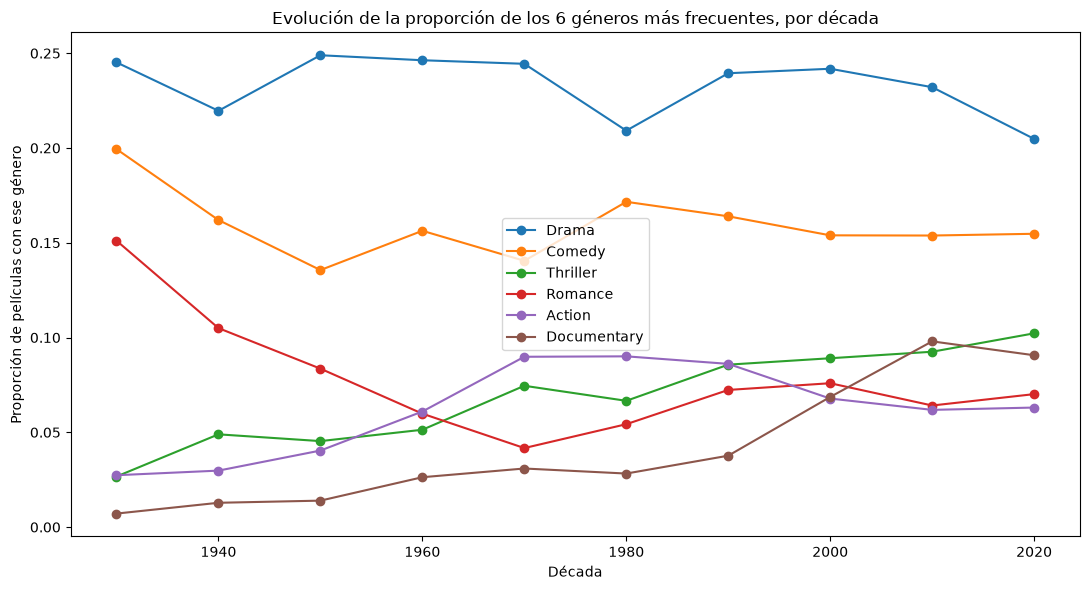

In [21]:
generos_top = frecuencias_genero.drop('None').head(6).index.tolist()

exploded = movies[['decada'] + genre_cols].melt(id_vars='decada', var_name='genero', value_name='pertenece')
exploded = exploded[exploded['pertenece'] == 1]

conteo_decada_genero = exploded.groupby(['decada', 'genero']).size().unstack(fill_value=0)
proporcion_decada_genero = conteo_decada_genero.div(conteo_decada_genero.sum(axis=1), axis=0)
proporcion_decada_genero = proporcion_decada_genero[proporcion_decada_genero.index >= 1930]

plt.figure(figsize=(11, 6))
for genero in generos_top:
    plt.plot(proporcion_decada_genero.index, proporcion_decada_genero[genero], marker='o', label=genero)

plt.xlabel('Década')
plt.ylabel('Proporción de películas con ese género')
plt.title('Evolución de la proporción de los 6 géneros más frecuentes, por década')
plt.legend()
plt.tight_layout()
plt.show()

**Resultados:** el promedio de géneros por película se mantiene relativamente estable, con una leve tendencia al alza desde mediados del siglo XX. En el segundo gráfico (restringido a 1930+ por tamaño de muestra), `Drama` se mantiene como el género más constante en todo el periodo; `Action` y `Thriller` muestran tendencia creciente desde mediados de siglo; `Romance` pierde peso relativo desde los años 60; `Documentary` crece notablemente desde los años 2000.

## Resumen de hallazgos principales y conclusiones

**Hallazgos principales:**

- El catálogo tiene 86,967 películas sin nulos ni `movieId` duplicados, cubriendo un periodo de 1874 a 2023, pero fuertemente concentrado en las décadas de 2000 y 2010.
- `Drama` y `Comedy` son, por amplio margen, los géneros más frecuentes; `Film-Noir` es el más raro entre los géneros válidos. Cerca del 7.7% de las películas no tiene género válido asignado.
- La mayoría de las películas está etiquetada con 1 o 2 géneros (mediana = 1); asignar 4 o más géneros es estadísticamente atípico según la regla del IQR, pero no es un error de datos, dado que es una variable discreta y acotada.
- El promedio de géneros por película y la popularidad relativa de géneros como `Action`, `Thriller` y `Documentary` muestran cambios a lo largo de las décadas, mientras que `Drama` se mantiene estable como el género dominante.
